# 🎯 Mock Interview System — Fine-Tuned Version

**Model:** `google/flan-t5-base` → fine-tuned on your dataset

**Steps:**
1. Install & import
2. Upload dataset
3. Fine-tune model on Q&A pairs
4. Run mock interview with fine-tuned model

> Runtime → Change runtime type → **T4 GPU** select করো আগে

In [1]:
# ── Cell 1: Install ───────────────────────────────────────────────────────
%%capture
!pip install transformers sentencepiece accelerate datasets rouge-score -q

In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import random
import torch
import textwrap
import json
import re
import os
import zipfile
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 1), "GB")
else:
    print("WARNING: GPU নেই — fine-tuning অনেক slow হবে. Runtime > GPU enable করো.")

Device: cpu


In [3]:
# ── Cell 3: Dataset upload ────────────────────────────────────────────────
from google.colab import files

print("Software Questions.csv অথবা archive.zip upload করো:")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith('.zip'):
    with zipfile.ZipFile(fname, 'r') as zf:
        zf.extractall('.')
    CSV_PATH = [f for f in os.listdir('.') if f.endswith('.csv')][0]
    print("Extracted CSV:", CSV_PATH)
else:
    CSV_PATH = fname
    print("Using CSV:", CSV_PATH)

Software Questions.csv অথবা archive.zip upload করো:


Saving Software Questions.csv to Software Questions (1).csv
Using CSV: Software Questions (1).csv


In [4]:
# ── Cell 4: Load & prepare dataset ───────────────────────────────────────
df = pd.read_csv(CSV_PATH, encoding='latin-1')
df['Category'] = df['Category'].str.strip()
df.loc[df['Category'] == 'General Program', 'Category'] = 'General Programming'
df['Question'] = df['Question'].astype(str).str.strip()
df['Answer']   = df['Answer'].astype(str).str.strip()

print(f"Total questions: {len(df)}")
print(f"Categories: {df['Category'].nunique()}")
print(f"\nSample:")
print("Q:", df['Question'].iloc[0])
print("A:", df['Answer'].iloc[0])

Total questions: 200
Categories: 21

Sample:
Q: What is the difference between compilation and interpretation?
A: Compilation translates source code into machine code creating an executable file. Interpretation translates and executes code line by line without an executable.


In [5]:
# ── Cell 5: Load base model ───────────────────────────────────────────────
MODEL_NAME = "google/flan-t5-base"
print(f"Loading {MODEL_NAME}...")

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model     = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32   # float32 for stable fine-tuning
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded! Parameters: {total_params/1e6:.1f}M")

Loading google/flan-t5-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded! Parameters: 247.6M


In [6]:
# ── Cell 6: Prepare fine-tuning data ─────────────────────────────────────
#
# Fine-tuning strategy:
# Input  → "answer this software interview question: {question}"
# Output → "{correct answer}"
#
# Model শিখবে: software interview question দিলে
# সে নিজেই correct answer generate করতে পারে
# এটা পরে evaluation এর সময় reference হিসেবে কাজ করবে

class InterviewDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_input_len=256, max_target_len=128):
        self.data           = dataframe.reset_index(drop=True)
        self.tokenizer      = tokenizer
        self.max_input_len  = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Input prompt
        input_text = (
            f"Answer this software engineering interview question. "
            f"Category: {row['Category']}. "
            f"Difficulty: {row['Difficulty']}. "
            f"Question: {row['Question']}"
        )
        target_text = row['Answer']

        # Tokenize input
        enc = self.tokenizer(
            input_text,
            max_length=self.max_input_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Tokenize target
        tgt = self.tokenizer(
            target_text,
            max_length=self.max_target_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        labels = tgt['input_ids'].squeeze()
        # padding token কে -100 করো (loss calculate এ ignore হবে)
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         labels
        }


# Train/Val split — 90% train, 10% validation
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx   = int(0.9 * len(df_shuffled))
df_train    = df_shuffled[:split_idx]
df_val      = df_shuffled[split_idx:]

train_dataset = InterviewDataset(df_train, tokenizer)
val_dataset   = InterviewDataset(df_val,   tokenizer)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)

print(f"Train samples : {len(df_train)}")
print(f"Val samples   : {len(df_val)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train samples : 180
Val samples   : 20
Train batches : 45
Val batches   : 5


In [7]:
# ── Cell 7: Fine-tuning ───────────────────────────────────────────────────
#
# Hyperparameters:
# EPOCHS=5  → 200 samples, 5 epochs = ~45 মিনিট (T4 GPU)
# LR=3e-4   → flan-t5-base এর জন্য optimal
# batch=4   → T4 VRAM (16GB) এর জন্য safe

EPOCHS    = 5
LR        = 3e-4
SAVE_PATH = "/content/flan_t5_interview_finetuned"

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"Starting fine-tuning for {EPOCHS} epochs...")
print("─" * 55)

best_val_loss  = float('inf')
train_losses   = []
val_losses     = []

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]")
    for batch in pbar:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()

        # Gradient clipping — training stable রাখে
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        epoch_train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]  "):
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            epoch_val_loss += outputs.loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Best model save
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        print(f"  ✅ Best model saved (val_loss={best_val_loss:.4f})")

print("─" * 55)
print(f"Fine-tuning complete! Best val loss: {best_val_loss:.4f}")
print(f"Model saved to: {SAVE_PATH}")

Total steps  : 225
Warmup steps : 22
Starting fine-tuning for 5 epochs...
───────────────────────────────────────────────────────


Epoch 1/5 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1/5 [Val]  :   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 8.9472 | Val Loss: 7.4839


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 5/5 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 5/5 [Val]  :   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 6.3493 | Val Loss: 5.9184


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_loss=5.9184)
───────────────────────────────────────────────────────
Fine-tuning complete! Best val loss: 5.9184
Model saved to: /content/flan_t5_interview_finetuned


In [8]:
# ── Cell 8: Load fine-tuned model ────────────────────────────────────────
print("Loading fine-tuned model...")

ft_tokenizer = T5Tokenizer.from_pretrained(SAVE_PATH)
ft_model     = T5ForConditionalGeneration.from_pretrained(
    SAVE_PATH,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)
ft_model.eval()

print("Fine-tuned model loaded and ready!")

Loading fine-tuned model...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Fine-tuned model loaded and ready!


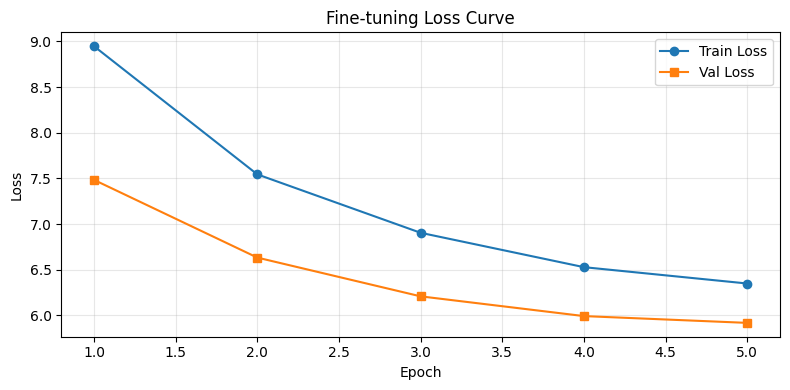

Loss curve saved.


In [9]:
# ── Cell 9: Loss curve plot ───────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, len(val_losses)+1),   val_losses,   marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tuning Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Loss curve saved.")

In [10]:
# ── Cell 10: Evaluation engine (fine-tuned version) ───────────────────────
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)


def generate_model_answer(question: str, category: str, difficulty: str) -> str:
    """
    Fine-tuned model দিয়ে question এর ideal answer generate করে।
    এটা reference answer হিসেবে ব্যবহার হবে।
    """
    prompt = (
        f"Answer this software engineering interview question. "
        f"Category: {category}. "
        f"Difficulty: {difficulty}. "
        f"Question: {question}"
    )
    inputs = ft_tokenizer(
        prompt,
        return_tensors='pt',
        max_length=256,
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return ft_tokenizer.decode(outputs[0], skip_special_tokens=True)


def evaluate_answer(question: str, user_answer: str,
                    correct_answer: str, category: str, difficulty: str) -> dict:
    """
    User answer evaluate করে:
    - Fine-tuned model এর generated answer এর সাথে তুলনা
    - Dataset এর correct answer এর সাথে তুলনা
    - দুটো মিলিয়ে final score
    """
    # Fine-tuned model এর reference answer
    model_ref_answer = generate_model_answer(question, category, difficulty)

    # ── ROUGE vs dataset answer ───────────────────────────────────────────
    rouge_vs_dataset  = scorer.score(correct_answer.lower(), user_answer.lower())
    rouge_l_dataset   = rouge_vs_dataset['rougeL'].fmeasure

    # ── ROUGE vs model generated answer ──────────────────────────────────
    rouge_vs_model    = scorer.score(model_ref_answer.lower(), user_answer.lower())
    rouge_l_model     = rouge_vs_model['rougeL'].fmeasure

    # ── Keyword match (dataset answer keywords) ───────────────────────────
    correct_words     = set(re.findall(r'\b\w{4,}\b', correct_answer.lower()))
    user_words        = set(re.findall(r'\b\w{4,}\b', user_answer.lower()))
    keyword_score     = len(correct_words & user_words) / max(len(correct_words), 1)

    # ── Length score ──────────────────────────────────────────────────────
    len_ratio         = min(len(user_answer.split()) / max(len(correct_answer.split()), 1), 1.5)
    len_score         = min(len_ratio, 1.0)

    # ── Combined score ────────────────────────────────────────────────────
    # dataset ROUGE 30% + model ROUGE 30% + keyword 25% + length 15%
    combined   = (0.30 * rouge_l_dataset +
                  0.30 * rouge_l_model   +
                  0.25 * keyword_score   +
                  0.15 * len_score)
    final_score = round(min(max(combined * 10, 0.0), 10.0), 1)

    # ── Verdict ───────────────────────────────────────────────────────────
    if final_score >= 8.0:
        verdict = "✅ Excellent!"
    elif final_score >= 6.0:
        verdict = "👍 Good"
    elif final_score >= 4.0:
        verdict = "⚠️  Needs Improvement"
    else:
        verdict = "❌ Incorrect / Incomplete"

    # ── Feedback ──────────────────────────────────────────────────────────
    kw_matched   = correct_words & user_words
    kw_missed    = correct_words - user_words
    feedback_parts = []

    if keyword_score >= 0.7:
        feedback_parts.append("Good keyword coverage.")
    elif keyword_score >= 0.4:
        feedback_parts.append(
            f"Partial keyword match. You missed: {', '.join(list(kw_missed)[:5])}."
        )
    else:
        feedback_parts.append(
            f"Low keyword coverage. Key terms missing: {', '.join(list(kw_missed)[:6])}."
        )

    if len_score < 0.5:
        feedback_parts.append("Answer is too short — add more detail.")
    elif len_score >= 0.9:
        feedback_parts.append("Good answer length.")

    if rouge_l_model >= 0.5:
        feedback_parts.append("Your answer aligns well with the expected answer.")
    elif rouge_l_model >= 0.3:
        feedback_parts.append("Partially matches expected answer structure.")
    else:
        feedback_parts.append("Review the correct answer structure below.")

    feedback = " ".join(feedback_parts)

    return {
        "score":              final_score,
        "verdict":            verdict,
        "feedback":           feedback,
        "model_ref_answer":   model_ref_answer,
        "correct_answer":     correct_answer,
        "rouge_l_dataset":    round(rouge_l_dataset, 3),
        "rouge_l_model":      round(rouge_l_model, 3),
        "keyword_match_pct":  round(keyword_score * 100, 1),
    }


print("Evaluation engine ready!")

Evaluation engine ready!


In [11]:
# ── Cell 11: Interview session ────────────────────────────────────────────
def print_sep(char="─", w=65):
    print(char * w)

def wprint(text, width=63, indent="  "):
    for line in textwrap.wrap(str(text), width=width):
        print(indent + line)


def run_mock_interview(
    category: str      = None,
    difficulty: str    = None,
    num_questions: int = 5
):
    # ── Filter ────────────────────────────────────────────────────────────
    pool = df.copy()
    if category:
        pool = pool[pool['Category'].str.lower() == category.lower()]
    if difficulty:
        pool = pool[pool['Difficulty'].str.lower() == difficulty.lower()]

    if len(pool) == 0:
        print("No questions found. Check category/difficulty spelling.")
        return

    questions = pool.sample(
        min(num_questions, len(pool)),
        random_state=random.randint(0, 9999)
    )

    # ── Header ────────────────────────────────────────────────────────────
    print_sep("═")
    print("  🎯 MOCK INTERVIEW  (Fine-Tuned Model)")
    print(f"  Category  : {category or 'Mixed'}")
    print(f"  Difficulty: {difficulty or 'Mixed'}")
    print(f"  Questions : {len(questions)}")
    print_sep("═")

    session_results = []

    for idx, (_, row) in enumerate(questions.iterrows(), 1):
        print(f"\n📌 Question {idx}/{len(questions)} "
              f"[{row['Category']} | {row['Difficulty']}]")
        print_sep()
        wprint(row['Question'])
        print_sep()

        # ── Answer input ──────────────────────────────────────────────────
        print("  ✏️  Your answer (Enter twice to submit | type 'skip' to skip):")
        lines = []
        while True:
            line = input("  > ")
            if line.lower() == "skip":
                lines = ["[skipped]"]
                break
            if line == "" and lines:
                break
            lines.append(line)
        user_answer = " ".join(lines).strip()

        if not user_answer or user_answer == "[skipped]":
            print("  ⏭️  Skipped.")
            session_results.append({
                "q_num": idx, "question": row['Question'],
                "category": row['Category'], "difficulty": row['Difficulty'],
                "score": 0.0, "verdict": "⏭️ Skipped",
                "keyword_match_pct": 0.0, "rouge_l_dataset": 0.0
            })
            continue

        # ── Evaluate ──────────────────────────────────────────────────────
        print("\n  ⏳ Evaluating with fine-tuned model...")
        result = evaluate_answer(
            row['Question'], user_answer,
            row['Answer'], row['Category'], row['Difficulty']
        )

        # ── Result display ────────────────────────────────────────────────
        print_sep()
        print(f"  📊 SCORE          : {result['score']}/10  {result['verdict']}")
        print(f"  🔑 Keyword Match  : {result['keyword_match_pct']}%")
        print(f"  📈 ROUGE-L (data) : {result['rouge_l_dataset']}")
        print(f"  🤖 ROUGE-L (model): {result['rouge_l_model']}")
        print()
        print("  💬 Feedback:")
        wprint(result['feedback'])
        print()
        print("  🤖 Model Reference Answer:")
        wprint(result['model_ref_answer'])
        print()
        print("  ✅ Dataset Correct Answer:")
        wprint(result['correct_answer'])
        print_sep()

        session_results.append({
            "q_num":             idx,
            "question":          row['Question'],
            "category":          row['Category'],
            "difficulty":        row['Difficulty'],
            "user_answer":       user_answer,
            "score":             result['score'],
            "verdict":           result['verdict'],
            "keyword_match_pct": result['keyword_match_pct'],
            "rouge_l_dataset":   result['rouge_l_dataset'],
            "rouge_l_model":     result['rouge_l_model'],
        })

        cont = input("  ▶️  Next? (Enter / 'q' to quit): ")
        if cont.lower() == 'q':
            break

    # ── Summary ───────────────────────────────────────────────────────────
    print_sep("═")
    print("  📋 SESSION SUMMARY")
    print_sep("═")

    answered = [r for r in session_results if r['verdict'] != '⏭️ Skipped']
    skipped  = [r for r in session_results if r['verdict'] == '⏭️ Skipped']

    if answered:
        scores = [r['score'] for r in answered]
        avg    = round(np.mean(scores), 2)

        print(f"  Attempted : {len(answered)}/{len(session_results)}")
        print(f"  Skipped   : {len(skipped)}")
        print(f"  Avg Score : {avg}/10")
        print(f"  Best      : {max(scores)}/10")
        print(f"  Worst     : {min(scores)}/10")
        print()
        print(f"  {'Q#':<4} {'Score':<8} {'Verdict':<25} Category")
        print("  " + "-"*60)
        for r in session_results:
            print(f"  {r['q_num']:<4} {str(r['score'])+'/10':<8} "
                  f"{r['verdict']:<25} {r['category']}")
        print()
        overall = ("🏆 Outstanding!" if avg>=8 else
                   "✅ Good!" if avg>=6 else
                   "📚 Keep practicing." if avg>=4 else
                   "💪 Review and retry.")
        print(f"  {overall}")
    else:
        print("  No questions answered.")

    print_sep("═")
    return session_results


print("Interview system ready! Go to Cell 12 to start.")

Interview system ready! Go to Cell 12 to start.


In [ ]:








# ── Cell 12: START INTERVIEW ──────────────────────────────────────────────
#
# category options:
#   "Data Structures", "Algorithms", "System Design",
#   "Database and SQL", "Web Development", "Machine Learning",
#   "Security", "DevOps", "Front-end", "Back-end", "Full-stack",
#   "Networking", "Languages and Frameworks", "Software Testing",
#   "Version Control", "Distributed Systems", "General Programming"
#   None = all categories
#
# difficulty: "Easy" | "Medium" | "Hard" | None

results = run_mock_interview(
    category      = None,
    difficulty    = None,
    num_questions = 5
)

═════════════════════════════════════════════════════════════════
  🎯 MOCK INTERVIEW  (Fine-Tuned Model)
  Category  : Mixed
  Difficulty: Mixed
  Questions : 5
═════════════════════════════════════════════════════════════════

📌 Question 1/5 [System Design | Hard]
─────────────────────────────────────────────────────────────────
  How do you ensure data consistency in a distributed database?
─────────────────────────────────────────────────────────────────
  ✏️  Your answer (Enter twice to submit | type 'skip' to skip):
  > balancing the CAP theorem's trade-offs using techniques like consensus algorithms
  > 

  ⏳ Evaluating with fine-tuned model...
─────────────────────────────────────────────────────────────────
  📊 SCORE          : 1.4/10  ❌ Incorrect / Incomplete
  🔑 Keyword Match  : 7.7%
  📈 ROUGE-L (data) : 0.071
  🤖 ROUGE-L (model): 0.0

  💬 Feedback:
  Low keyword coverage. Key terms missing: commits, ensure,
  optimistic, models, phase, resolution. Review the correct
  answer

In [ ]:
# ── Cell 13: (Optional) Save fine-tuned model to Google Drive ─────────────
from google.colab import drive
import shutil

drive.mount('/content/drive')

drive_save_path = "/content/drive/MyDrive/flan_t5_interview_finetuned"
if os.path.exists(SAVE_PATH):
    shutil.copytree(SAVE_PATH, drive_save_path, dirs_exist_ok=True)
    print(f"Model saved to Drive: {drive_save_path}")
else:
    print("Model not found. Run Cell 7 first.")

In [ ]:
# ── Cell 14: (Optional) Load from Drive (next session এ) ──────────────────
# Colab disconnect হলে fine-tuning আবার করতে হবে না
# এই cell run করলে Drive থেকে model load হবে

from google.colab import drive
drive.mount('/content/drive')

drive_model_path = "/content/drive/MyDrive/flan_t5_interview_finetuned"

ft_tokenizer = T5Tokenizer.from_pretrained(drive_model_path)
ft_model     = T5ForConditionalGeneration.from_pretrained(
    drive_model_path,
    torch_dtype=torch.float16 if DEVICE=="cuda" else torch.float32
).to(DEVICE)
ft_model.eval()
print("Fine-tuned model loaded from Drive!")